In [5]:
### import pandas as pd
import re
import numpy as np
import pandas as pd

# Nome del file
file_name ="IMAGENET_comp.txt" #"CIFAR10_comp.txt"

# -----------------------------
# 1. FUNZIONI DI PULIZIA
# -----------------------------

def extract_mean_std(value_str, column_name):
    """
    Estrae la media e la deviazione standard da una stringa.
    Normalizza la media del coverage a [0, 1] se è in percentuale.
    Gestisce la stringa '---' sostituendola con np.nan.
    """
    # 1. Assicura che l'input sia una stringa e gestisce la stringa '---'
    value_str_str = str(value_str).strip()
    if value_str_str == '---':
        # Se è '---', restituisci NaN
        return np.nan, np.nan
    
    # Sostituisce i simboli comuni di "più o meno" con "±" per uniformità
    value_str_clean = value_str_str.replace('\u00b1', '±').replace('\\pm', '±').strip()
    
    mean = np.nan
    std = np.nan
    
    try:
        # Tenta di suddividere la stringa in base al simbolo "±"
        if '±' in value_str_clean:
            parts = value_str_clean.split('±')
            mean = float(parts[0].strip())
            std = float(parts[1].strip())
        else:
            # Se non c'è "±", la deviazione standard è 0
            mean = float(value_str_clean)
            std = 0.0
            
    except ValueError:
        print(f"Attenzione: Impossibile convertire il valore '{value_str_clean}' in numerico.")
        return np.nan, np.nan
    
    # Normalizzazione per la colonna 'coverage'
    if column_name == 'coverage':
        # Se la media è molto superiore a 1 (cioè è in percentuale, es. 90.0), la dividiamo per 100.
        if mean > 1.1: 
            mean /= 100.0
        if std > 0.1:# Assumendo che la deviazione standard fosse in percentuale, la dividiamo anche qui
            std /= 100.0
        
        # Gestione specifica per BINCP (come richiesto in precedenza)
        if "BINCP" in value_str_str and std != 0.0:
            std /= 100.0
            
    if column_name == 'size':
        
        if "BINCP" in value_str_str and std != 0.0:
            print("ciao")
            std /= 100.0
            
    return mean, std


# -----------------------------
# 2. CARICAMENTO E ELABORAZIONE DATI
# -----------------------------

# Carica i dati, specificando che sono separati da virgole e ignora gli spazi iniziali/finali
df = pd.read_csv(file_name, skipinitialspace=True)

# Applica la funzione 'extract_mean_std'
df[['coverage_mean', 'coverage_std']] = df.apply(
    lambda row: pd.Series(extract_mean_std(row['coverage'], 'coverage')), axis=1
)
df[['size_mean', 'size_std']] = df.apply(
    lambda row: pd.Series(extract_mean_std(row['size'], 'size')), axis=1
)


# Pulisci i nomi dei tipi di attacco
df['attack_type'] = df['attack_type'].str.strip()

# CORREZIONE: Pulisci la colonna 'eps', sostituendo '---' con NaN prima della conversione a float
df['eps'] = df['eps'].apply(lambda x: str(x).strip())
df['eps'] = df['eps'].replace('---', np.nan).astype(float)


# Seleziona solo le colonne utili e ordina per 'eps' (i valori NaN saranno posti alla fine se non gestiti)
df_clean = df[['attack_type', 'eps', 'coverage_mean', 'coverage_std', 'size_mean', 'size_std']].sort_values(by='eps', na_position='last').reset_index(drop=True)

# Stampa le prime righe del DataFrame pulito
print("--- DataFrame Pulito ---")
print(df_clean.head(20).to_markdown(index=False))
print(f"\nTotale righe: {len(df_clean)}")
print("\nDataFrame salvato in 'sdss_clean.csv'")

# Salva il dataframe pulito per riferimento
df_clean.to_csv("sdss_clean100.csv", index=False)

--- DataFrame Pulito ---
| attack_type   |   eps |   coverage_mean |   coverage_std |   size_mean |   size_std |
|:--------------|------:|----------------:|---------------:|------------:|-----------:|
| combined      | 0.005 |          0.914  |       0.002804 |     10.724  |     0.5435 |
| PGD_1_l2      | 0.005 |          0.914  |       0.002804 |     10.71   |     0.5425 |
| PGD_10_l2     | 0.005 |          0.914  |       0.002804 |     10.718  |     0.543  |
| PGD_100_l2    | 0.005 |          0.914  |       0.002804 |     10.722  |     0.5433 |
| BINCP         | 0.005 |          0.939  |       0.004963 |     13.5603 |     3.5136 |
| RCP1          | 0.005 |          0.942  |       0.0178   |     13.7817 |     0.1281 |
| HPS_verif_pre | 0.005 |          0.899  |       0.009    |     37.624  |     1.987  |
| HPS_RSCP+     | 0.005 |          1      |       0        |    200      |     0      |
| PTT_HPS_RSCP+ | 0.005 |          0.93   |       0.031    |     87.448  |    48.171  |
| HPS_v

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/tmp/ipykernel_1333711/3761295002.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/tmp/ipykernel_1333711/3761295002.py:215: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Grafici generati con PGD e combined inclusi.


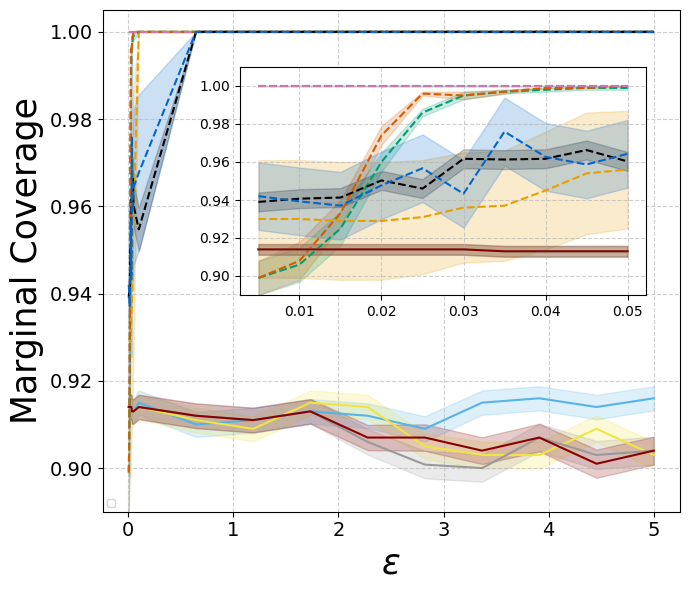

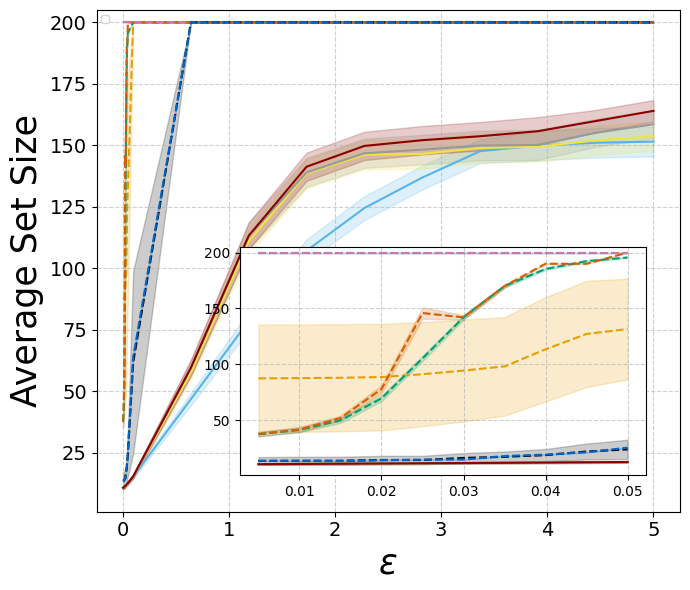

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# PARAMETRI DAL CODICE ORIGINALE
# -----------------------------
# Aggiungo PGD e combined
methods = [
    "HPS_RSCP+",
    "PTT_HPS_RSCP+",
    "HPS_verif",
    "HPS_verif_pre",
    "CAS-C",
    "BINCP",
    "RCP1",
    "PGD_1_l2",
    "PGD_10_l2",
    "PGD_100_l2",
    "combined"
]

label_methods = [
    "RSCP+",
    "RSCP+ (PTT)",
    "VRCP-I",
    "VRCP-C",
    "CAS-C",
    "BINCP",
    "RCP1",
    "PERCP\n(PGD1)",
    "PERCP\n(PGD10)",
    "PERCP\n(PGD100)",
    "PERCP\n(Worst)"
]

# Colori (aggiunti PGD e combined)
method_colors = {
    "HPS_RSCP+":      "#0072B2",  # Strong Blue
    "PTT_HPS_RSCP+":  "#E69F00",  # Orange
    "HPS_verif":      "#009E73",  # Bluish Green
    "HPS_verif_pre":  "#D55E00",  # Vermillion
    "CAS-C":          "#CC79A7",  # Reddish Purple
    "BINCP":          "#000000",  # Black
    "RCP1":           "#0066CC", # DodgerBlue
    "PGD_1_l2":       "#56B4E9",  # Sky Blue
    "PGD_10_l2":      "#F0E442",  # Yellow
    "PGD_100_l2":     "#999999",  # Grey
    "combined":       "#8B0000"   # Dark Red
}


# -----------------------------
# 1. CARICAMENTO DATI PULITI
# -----------------------------
df_clean = pd.read_csv("sdss_clean100.csv")

# Filtra solo i metodi di interesse
df_plot = df_clean[df_clean['attack_type'].isin(methods)].copy()
df_plot.sort_values(by='eps', inplace=True)

# Rimuove eventuali NaN
df_plot.dropna(subset=['coverage_mean', 'size_mean'], inplace=True)

extended_epsilons = df_plot['eps'].unique()
zoom_epsilons = extended_epsilons[:10]

# -----------------------------
# 2. PREPARAZIONE DATI PER IL PLOT
# -----------------------------
plot_data = {}
for method in methods:
    method_data = df_plot[df_plot['attack_type'] == method]
    
    if len(method_data) < len(extended_epsilons):
        n_missing = len(extended_epsilons) - len(method_data)
        
        if method_data.empty:
            cov_mean_fill, cov_std_fill = 1.0, 0.0
            size_mean_fill, size_std_fill = 100.0, 0.0
        else:
            cov_mean_fill  = method_data['coverage_mean'].iloc[-1]
            cov_std_fill   = method_data['coverage_std'].iloc[-1]
            size_mean_fill = method_data['size_mean'].iloc[-1]
            size_std_fill  = method_data['size_std'].iloc[-1]
        
        # Riempimento
        missing_cov_mean = np.concatenate([
            method_data['coverage_mean'].values,
            [cov_mean_fill] * n_missing
        ])
        missing_cov_std = np.concatenate([
            method_data['coverage_std'].values,
            [cov_std_fill] * n_missing
        ])
        missing_size_mean = np.concatenate([
            method_data['size_mean'].values,
            [size_mean_fill] * n_missing
        ])
        missing_size_std = np.concatenate([
            method_data['size_std'].values,
            [size_std_fill] * n_missing
        ])
    
    else:
        missing_cov_mean = method_data['coverage_mean'].values
        missing_cov_std = method_data['coverage_std'].values
        missing_size_mean = method_data['size_mean'].values
        missing_size_std = method_data['size_std'].values
    
    plot_data[method] = {
        'coverage_mean': missing_cov_mean,
        'coverage_std': missing_cov_std,
        'size_mean': missing_size_mean,
        'size_std': missing_size_std,
    }

# -----------------------------
# 3. PLOT 1: MARGINAL COVERAGE
# -----------------------------
fig1, ax1 = plt.subplots(figsize=(7, 6))
ax1_inset = fig1.add_axes([0.35, 0.50, 0.58, 0.38])

for method, label_method in zip(methods, label_methods):
    color = method_colors[method]
    data = plot_data[method]
    eps_to_plot = extended_epsilons[:len(data['coverage_mean'])]

    # Se il metodo è un PERCP method (PGD o combined), linea solida
    if "PERCP" in label_method:
        linestyle = '-'
    else:
        linestyle = '--'

    ax1.plot(eps_to_plot, data['coverage_mean'], linestyle=linestyle, color=color)
    ax1.fill_between(
        eps_to_plot,
        data['coverage_mean'] - data['coverage_std'],
        data['coverage_mean'] + data['coverage_std'],
        alpha=0.2,
        color=color
    )
    
    zoom_data = data['coverage_mean'][:len(zoom_epsilons)]
    zoom_std = data['coverage_std'][:len(zoom_epsilons)]

    ax1_inset.plot(zoom_epsilons, zoom_data, linestyle=linestyle, color=color)
    ax1_inset.fill_between(
        zoom_epsilons,
        zoom_data - zoom_std,
        zoom_data + zoom_std,
        alpha=0.2,
        color=color
    )

ax1.set_xlabel(r'$\varepsilon$', fontsize=25)
ax1.set_ylabel('Marginal Coverage', fontsize=25)
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='lower left', fontsize=7, ncol=2)
ax1.set_ylim(0.89, 1.005)

ax1_inset.tick_params(axis='both', which='major', labelsize=10)
ax1_inset.grid(True, linestyle='--', alpha=0.6)
ax1_inset.set_ylim(0.89, 1.01)

plt.tight_layout()


# -----------------------------
# 4. PLOT 2: AVERAGE SET SIZE
# -----------------------------
fig2, ax2 = plt.subplots(figsize=(7, 6))
ax2_inset = fig2.add_axes([0.35, 0.20, 0.58, 0.38])

for method, label_method in zip(methods, label_methods):
    color = method_colors[method]
    data = plot_data[method]
    eps_to_plot = extended_epsilons[:len(data['size_mean'])]

    linestyle = '-' if "PERCP" in label_method else '--'
    
    ax2.plot(eps_to_plot, data['size_mean'], linestyle=linestyle, color=color)
    ax2.fill_between(
        eps_to_plot,
        data['size_mean'] - data['size_std'],
        data['size_mean'] + data['size_std'],
        alpha=0.2,
        color=color
    )

    zoom_data = data['size_mean'][:len(zoom_epsilons)]
    zoom_std = data['size_std'][:len(zoom_epsilons)]

    ax2_inset.plot(zoom_epsilons, zoom_data, linestyle=linestyle, color=color)
    ax2_inset.fill_between(
        zoom_epsilons,
        zoom_data - zoom_std,
        zoom_data + zoom_std,
        alpha=0.2,
        color=color
    )

ax2.set_xlabel(r'$\varepsilon$', fontsize=25)
ax2.set_ylabel('Average Set Size', fontsize=25)
ax2.tick_params(axis='both', which='major', labelsize=14)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc='upper left', fontsize=7, ncol=2)
ax2.set_ylim(1, 205.0)

ax2_inset.tick_params(axis='both', which='major', labelsize=10)
ax2_inset.grid(True, linestyle='--', alpha=0.6)
ax2_inset.set_ylim(1.0, 205.0)

plt.tight_layout()

print("Grafici generati con PGD e combined inclusi.")


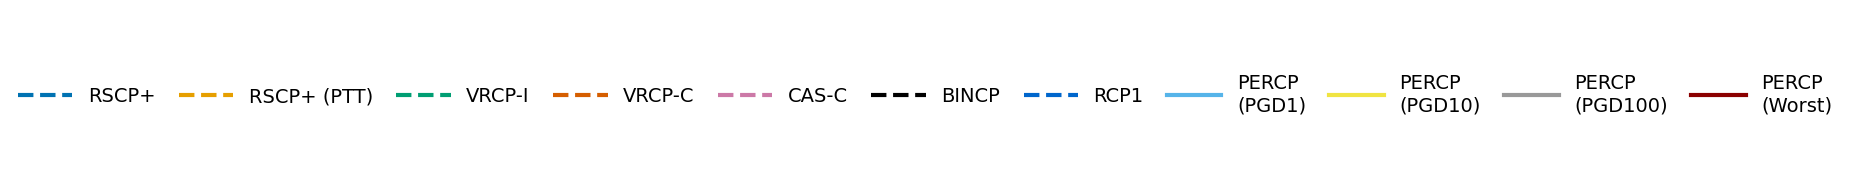

In [106]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# -------------------------------------------------------------------
# LEGGENDA SOLO PER I METODI PRESENTI NEL PLOT (VRCP + CAS-C + BINCP + PERCP)
# -------------------------------------------------------------------

method_handles = []
for method, label in zip(methods, label_methods):
    color = method_colors[method]
    # Se è un PERCP method, linea solida, altrimenti tratteggiata
    linestyle = '-' if "PERCP" in label else '--'
    handle = Line2D([0], [0], color=color, linestyle=linestyle, lw=3)
    method_handles.append(handle)

# -------------------------------------------------------------------
# CREAZIONE LEGGENDA FIGURA
# -------------------------------------------------------------------

legend_fig = plt.figure(figsize=(12, 2.2))
legend_ax = legend_fig.add_subplot(111)

legend_ax.legend(
    method_handles,
    label_methods,
    loc='center',
    ncol=len(label_methods),
    fontsize=14,
    frameon=False,
    handlelength=2.8,
    columnspacing=1.2
)

legend_ax.axis('off')

# Salvataggio
legend_fig.savefig("legend_methods.pdf", bbox_inches='tight', dpi=300)
legend_fig.savefig("legend_methods.png", bbox_inches='tight', dpi=300, transparent=True)

#plt.close(legend_fig)


/tmp/ipykernel_1333711/328263576.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1333711/328263576.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


NeurIPS-quality plots generated (no legend).


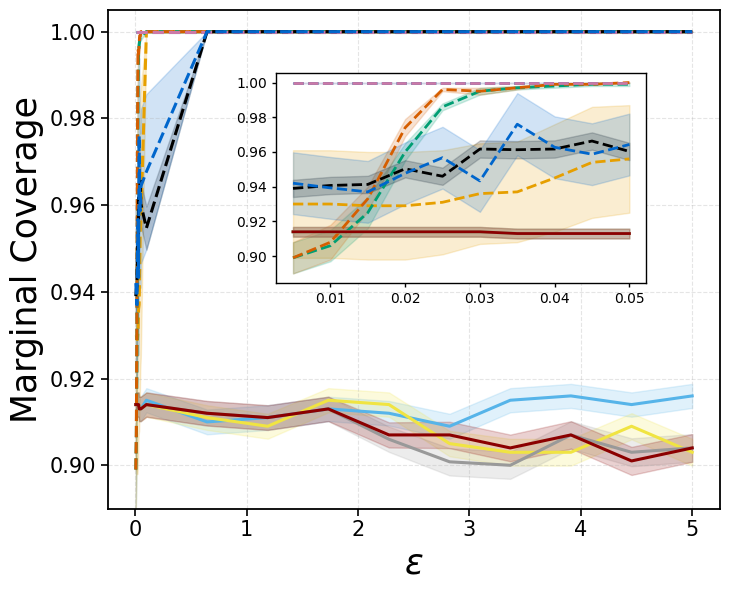

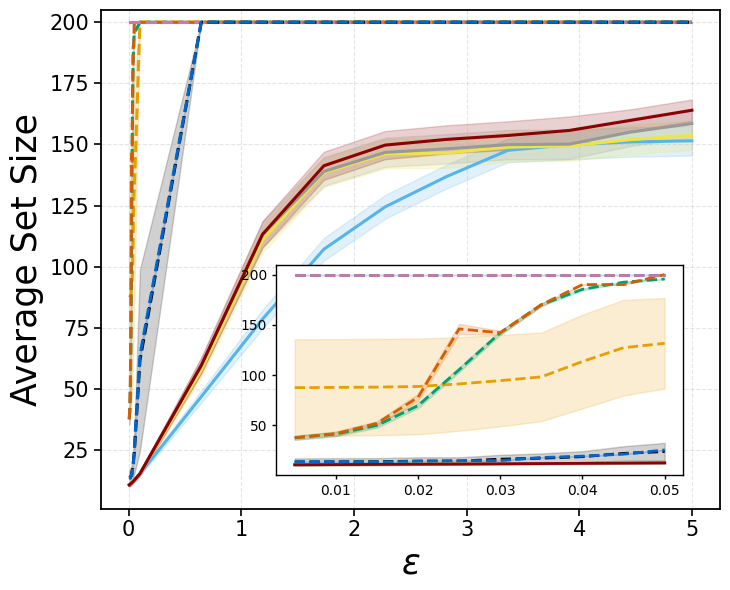

In [14]:
import matplotlib.pyplot as plt

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["axes.linewidth"] = 1.3

# -----------------------------
# FUNZIONI PER STILE NEURIPS
# -----------------------------
def style_neurips(ax):
    ax.grid(True, linestyle="--", alpha=0.32)
    ax.tick_params(axis="both", labelsize=15, width=1.2, length=5)
    for spine in ax.spines.values():
        spine.set_linewidth(1.3)

def inset_style(ax):
    ax.tick_params(axis="both", labelsize=10, width=1.0, length=3)
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)

# -----------------------------
# PLOT 1 — MARGINAL COVERAGE
# -----------------------------
fig1, ax1 = plt.subplots(figsize=(7.4, 6.0))
ax1_inset = fig1.add_axes([0.38, 0.52, 0.50, 0.35])  # inset ben allineato

for method, label_method in zip(methods, label_methods):
    color = method_colors[method]
    data = plot_data[method]
    eps = extended_epsilons[:len(data["coverage_mean"])]

    linestyle = "-" if "PERCP" in label_method else "--"

    # main plot
    ax1.plot(eps, data["coverage_mean"], color=color, linewidth=2.2, linestyle=linestyle)
    ax1.fill_between(
        eps,
        data["coverage_mean"] - data["coverage_std"],
        data["coverage_mean"] + data["coverage_std"],
        alpha=0.18,
        color=color
    )

    # inset
    zm = data["coverage_mean"][:len(zoom_epsilons)]
    zs = data["coverage_std"][:len(zoom_epsilons)]

    ax1_inset.plot(zoom_epsilons, zm, color=color, linewidth=2.0, linestyle=linestyle)
    ax1_inset.fill_between(
        zoom_epsilons,
        zm - zs,
        zm + zs,
        alpha=0.18,
        color=color
    )

style_neurips(ax1)
inset_style(ax1_inset)

ax1.set_xlabel(r"$\varepsilon$", fontsize=25)
ax1.set_ylabel("Marginal Coverage", fontsize=25)
ax1.set_ylim(0.89, 1.005)

plt.tight_layout()


# -----------------------------
# PLOT 2 — AVERAGE SET SIZE
# -----------------------------
fig2, ax2 = plt.subplots(figsize=(7.4, 6.0))
ax2_inset = fig2.add_axes([0.38, 0.20, 0.55, 0.35])  # inset ben posizionato

for method, label_method in zip(methods, label_methods):
    color = method_colors[method]
    data = plot_data[method]
    eps = extended_epsilons[:len(data["size_mean"])]

    linestyle = "-" if "PERCP" in label_method else "--"

    ax2.plot(eps, data["size_mean"], color=color, linewidth=2.2, linestyle=linestyle)
    ax2.fill_between(
        eps,
        data["size_mean"] - data["size_std"],
        data["size_mean"] + data["size_std"],
        color=color,
        alpha=0.18
    )

    # inset
    zm = data["size_mean"][:len(zoom_epsilons)]
    zs = data["size_std"][:len(zoom_epsilons)]

    ax2_inset.plot(zoom_epsilons, zm, color=color, linewidth=2.0, linestyle=linestyle)
    ax2_inset.fill_between(
        zoom_epsilons,
        zm - zs,
        zm + zs,
        alpha=0.18,
        color=color
    )

style_neurips(ax2)
inset_style(ax2_inset)

ax2.set_xlabel(r"$\varepsilon$", fontsize=25)
ax2.set_ylabel("Average Set Size", fontsize=25)
ax2.set_ylim(1.0, 205)

plt.tight_layout()

fig1.savefig("coverage_IMAGENET.pdf", bbox_inches='tight', dpi=300)
fig2.savefig("size_IMAGENET.pdf", bbox_inches='tight', dpi=300)

print("NeurIPS-quality plots generated (no legend).")
